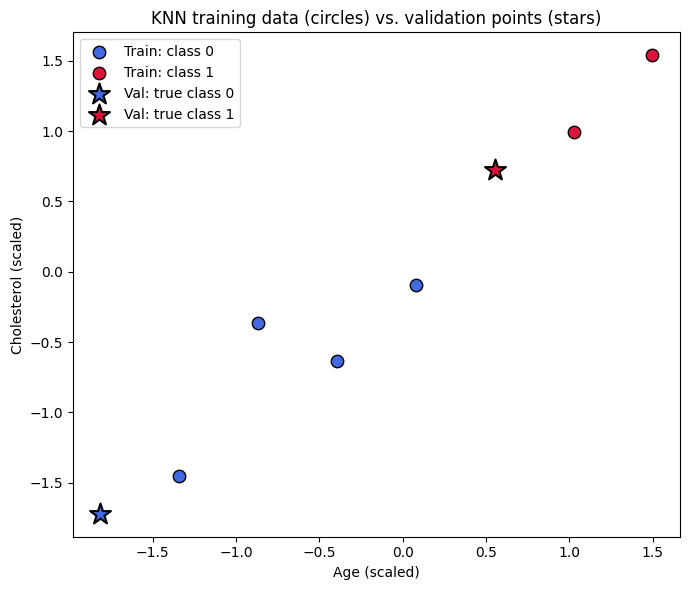

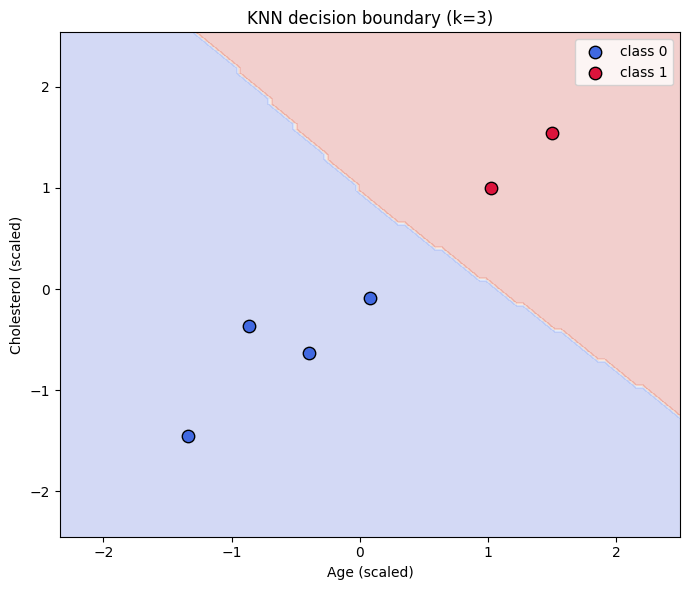

Predictions: [1 0]
True labels: [1 0]
Accuracy: 100.0 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


# ---------------------------------------------------------------------------
# STEP 1: Distance function
# ---------------------------------------------------------------------------
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


# ---------------------------------------------------------------------------
# STEP 2: Feature scaling (z-score standardization)
# ---------------------------------------------------------------------------
def fit_scaler(X_train):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1
    return mean, std


def apply_scaler(X, mean, std):
    return (X - mean) / std


# ---------------------------------------------------------------------------
# STEP 3: Predict a single point
# ---------------------------------------------------------------------------
def predict_one(X_train, y_train, x_query, k):
    distances = np.array([euclidean_distance(x_query, x_train_i) for x_train_i in X_train])
    k_nearest_indices = np.argsort(distances)[:k]
    k_nearest_labels = y_train[k_nearest_indices]
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]


def knn_predict(X_train, y_train, X_query, k):
    return np.array([predict_one(X_train, y_train, x, k) for x in X_query])


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


# ---------------------------------------------------------------------------
# STEP 4 (NEW): Visualize the raw data
# Plots training points colored by class label, and validation/query
# points marked with a different symbol so you can see where they
# land relative to the training data BEFORE looking at predictions.
# Only works directly for 2 features (2D plot) — for more features
# you'd need PCA/t-SNE to reduce to 2D first.
# ---------------------------------------------------------------------------
def plot_data(X_train, y_train, X_val=None, y_val=None, feature_names=("Feature 1", "Feature 2")):
    plt.figure(figsize=(7, 6))

    # training points: color by class (0 = blue circle, 1 = red circle)
    plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
                c="royalblue", label="Train: class 0", edgecolor="k", s=80)
    plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
                c="crimson", label="Train: class 1", edgecolor="k", s=80)

    # validation/query points: same colors but marked with a star + black outline
    if X_val is not None and y_val is not None:
        plt.scatter(X_val[y_val == 0, 0], X_val[y_val == 0, 1],
                    c="royalblue", marker="*", s=250, edgecolor="black", linewidth=1.5,
                    label="Val: true class 0")
        plt.scatter(X_val[y_val == 1, 0], X_val[y_val == 1, 1],
                    c="crimson", marker="*", s=250, edgecolor="black", linewidth=1.5,
                    label="Val: true class 1")

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("KNN training data (circles) vs. validation points (stars)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# STEP 5 (NEW): Visualize the decision boundary
# Builds a fine grid covering the feature space, predicts a class for
# every grid point using the SAME knn_predict function, then colors the
# background by predicted class. This shows visually what region of
# feature space each class "owns" for a given k, and lets you literally
# see the boundary get jagged (small k) or smooth (large k).
# ---------------------------------------------------------------------------
def plot_decision_boundary(X_train, y_train, k, feature_names=("Feature 1", "Feature 2"), resolution=100):
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])

    # predict class for every point on the grid (reuses the same knn_predict)
    grid_preds = knn_predict(X_train, y_train, grid_points, k)
    grid_preds = grid_preds.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, grid_preds, alpha=0.25, cmap="coolwarm")

    plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
                c="royalblue", label="class 0", edgecolor="k", s=80)
    plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
                c="crimson", label="class 1", edgecolor="k", s=80)

    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(f"KNN decision boundary (k={k})")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# EXAMPLE USAGE: visualize the data, THEN predict
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # toy data: [age, cholesterol]
    X = np.array([
        [45, 180], [50, 200], [60, 240], [35, 150],
        [65, 260], [40, 190], [55, 230], [30, 140],
    ])
    y = np.array([0, 0, 1, 0, 1, 0, 1, 0])

    X_train, y_train = X[:6], y[:6]
    X_val, y_val = X[6:], y[6:]

    # fit scaler on TRAIN only, apply to both
    mean, std = fit_scaler(X_train)
    X_train_scaled = apply_scaler(X_train, mean, std)
    X_val_scaled = apply_scaler(X_val, mean, std)

    # --- VISUALIZE FIRST (using scaled coordinates, same space the model sees) ---
    plot_data(X_train_scaled, y_train, X_val_scaled, y_val,
              feature_names=("Age (scaled)", "Cholesterol (scaled)"))

    k = 3
    plot_decision_boundary(X_train_scaled, y_train, k,
                            feature_names=("Age (scaled)", "Cholesterol (scaled)"))

    # --- THEN PREDICT ---
    predictions = knn_predict(X_train_scaled, y_train, X_val_scaled, k)

    print("Predictions:", predictions)
    print("True labels:", y_val)
    print("Accuracy:", accuracy(y_val, predictions) * 100, "%")

